<a href="https://colab.research.google.com/github/ALIA-HAIDER/CodeScope/blob/main/Codescope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!ls /content/drive/MyDrive/MiniProject_CodeScope


Test_data.zip  Train_data.zip


In [3]:
!cp /content/drive/MyDrive/MiniProject_CodeScope/Test_data.zip /content/
!cp /content/drive/MyDrive/MiniProject_CodeScope/Train_data.zip /content/

In [4]:
!unzip /content/Test_data.zip

Archive:  /content/Test_data.zip
replace Test_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [5]:
!unzip /content/Train_data.zip

Archive:  /content/Train_data.zip
replace Train_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [6]:
!ls

drive	     Test_data.csv  Train_data.csv
sample_data  Test_data.zip  Train_data.zip


In [8]:
# datasep importing done
# now  we need to pre-process the data according to our need

In [7]:
import pandas as pd
import numpy as np


In [8]:
train =pd.read_csv("Train_data.csv")
test=pd.read_csv("Test_data.csv")

In [9]:
train.head()

,Index,LOC_BLANK,BRANCH_COUNT,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CYCLOMATIC_COMPLEXITY,DESIGN_COMPLEXITY,ESSENTIAL_COMPLEXITY,LOC_EXECUTABLE,HALSTEAD_CONTENT,...,HALSTEAD_LENGTH,HALSTEAD_LEVEL,HALSTEAD_PROG_TIME,HALSTEAD_VOLUME,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,LOC_TOTAL,Defect
0,0,0,3,0,0,2,2,1,5,17.08,...,18,0.29,11.63,59.79,3,15,3,7,7,1
1,1,1,1,0,0,1,1,1,8,28.00,...,21,0.33,14.00,84.00,10,11,10,6,14,0
2,2,0,1,0,0,1,1,1,0,7.74,...,5,0.67,0.97,11.61,2,3,2,3,2,0
3,3,0,1,0,2,1,1,1,4,6.67,...,10,0.22,7.50,30.00,3,7,2,6,8,0
4,4,2,3,1,3,2,2,1,14,30.86,...,36,0.21,37.33,144.00,12,24,9,7,22,0


In [10]:
test.head()

,Index,LOC_BLANK,BRANCH_COUNT,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CYCLOMATIC_COMPLEXITY,DESIGN_COMPLEXITY,ESSENTIAL_COMPLEXITY,LOC_EXECUTABLE,HALSTEAD_CONTENT,...,HALSTEAD_ERROR_EST,HALSTEAD_LENGTH,HALSTEAD_LEVEL,HALSTEAD_PROG_TIME,HALSTEAD_VOLUME,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,LOC_TOTAL
0,0,0,1,0,0,1,1,1,0,5.33,...,0.00,4,0.67,0.67,8.00,1,3,1,3,2
1,1,2,3,0,0,2,2,1,10,15.99,...,0.04,28,0.15,39.48,106.61,10,18,6,8,15
2,2,1,5,0,0,3,3,1,9,19.93,...,0.02,15,0.40,6.92,49.83,5,10,5,5,12
3,3,0,1,0,0,1,1,1,1,0.00,...,0.00,1,0.00,0.00,0.00,0,1,0,1,3
4,4,0,1,0,0,1,1,1,0,5.33,...,0.00,4,0.67,0.67,8.00,1,3,1,3,2


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Index                  1676 non-null   int64  
 1   LOC_BLANK              1676 non-null   int64  
 2   BRANCH_COUNT           1676 non-null   int64  
 3   LOC_CODE_AND_COMMENT   1676 non-null   int64  
 4   LOC_COMMENTS           1676 non-null   int64  
 5   CYCLOMATIC_COMPLEXITY  1676 non-null   int64  
 6   DESIGN_COMPLEXITY      1676 non-null   int64  
 7   ESSENTIAL_COMPLEXITY   1676 non-null   int64  
 8   LOC_EXECUTABLE         1676 non-null   int64  
 9   HALSTEAD_CONTENT       1676 non-null   float64
 10  HALSTEAD_DIFFICULTY    1676 non-null   float64
 11  HALSTEAD_EFFORT        1676 non-null   float64
 12  HALSTEAD_ERROR_EST     1676 non-null   float64
 13  HALSTEAD_LENGTH        1676 non-null   int64  
 14  HALSTEAD_LEVEL         1676 non-null   float64
 15  HALS

In [12]:
train.isnull().sum()

,0
Index,0
LOC_BLANK,0
BRANCH_COUNT,0
LOC_CODE_AND_COMMENT,0
LOC_COMMENTS,0
CYCLOMATIC_COMPLEXITY,0
DESIGN_COMPLEXITY,0
ESSENTIAL_COMPLEXITY,0
LOC_EXECUTABLE,0
HALSTEAD_CONTENT,0


In [13]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Index                  419 non-null    int64  
 1   LOC_BLANK              419 non-null    int64  
 2   BRANCH_COUNT           419 non-null    int64  
 3   LOC_CODE_AND_COMMENT   419 non-null    int64  
 4   LOC_COMMENTS           419 non-null    int64  
 5   CYCLOMATIC_COMPLEXITY  419 non-null    int64  
 6   DESIGN_COMPLEXITY      419 non-null    int64  
 7   ESSENTIAL_COMPLEXITY   419 non-null    int64  
 8   LOC_EXECUTABLE         419 non-null    int64  
 9   HALSTEAD_CONTENT       419 non-null    float64
 10  HALSTEAD_DIFFICULTY    419 non-null    float64
 11  HALSTEAD_EFFORT        419 non-null    float64
 12  HALSTEAD_ERROR_EST     419 non-null    float64
 13  HALSTEAD_LENGTH        419 non-null    int64  
 14  HALSTEAD_LEVEL         419 non-null    float64
 15  HALSTE

# creating additional Target variable


In [16]:
# 1-> Complexity level
def complexity_level(x):
  if x<5:
    return 0
  elif x<10:
    return 1
  else:
    return 2

train["complexity_level"] = train["CYCLOMATIC_COMPLEXITY"].apply(complexity_level)
test["complexity_level"] = test["CYCLOMATIC_COMPLEXITY"].apply(complexity_level)


In [15]:
# 2->MAintainability score
#171 - 5.2 * ln(Halstead Volume)
    #  - 0.23 * Cyclomatic Complexity
    #  - 16.2 * ln(LOC)

In [18]:
train["maintainability_score"]=(
    171-5.2*np.log(train["HALSTEAD_VOLUME"])-0.23*train["CYCLOMATIC_COMPLEXITY"]-16.2*np.log(train["LOC_TOTAL"])
)

test["maintainability_score"]=(
    171-5.2*np.log(test["HALSTEAD_VOLUME"])-0.23*test["CYCLOMATIC_COMPLEXITY"]-16.2*np.log(test["LOC_TOTAL"])
)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [19]:
# 3-> Code Smell
# High complexity + large LOC = smell
train["code_smell_risk"]=(
    (train['CYCLOMATIC_COMPLEXITY']>10) &(train["LOC_TOTAL"]>200)
).astype(int)

test["code_smell_risk"]=(
    (test['CYCLOMATIC_COMPLEXITY']>10) &(test["LOC_TOTAL"]>200)
).astype(int)

In [20]:
# 4->Technical Debt
# technical Dept =complexity+halstead effort +Loc
test["techincal_debt"]=(test["CYCLOMATIC_COMPLEXITY"]+test["HALSTEAD_EFFORT"]*0.001+test["LOC_TOTAL"])

train["techincal_debt"]=(train["CYCLOMATIC_COMPLEXITY"]+train["HALSTEAD_EFFORT"]*0.001+train["LOC_TOTAL"])

In [13]:
print(train.columns
      )

Index(['Index', 'LOC_BLANK', 'BRANCH_COUNT', 'LOC_CODE_AND_COMMENT',
       'LOC_COMMENTS', 'CYCLOMATIC_COMPLEXITY', 'DESIGN_COMPLEXITY',
       'ESSENTIAL_COMPLEXITY', 'LOC_EXECUTABLE', 'HALSTEAD_CONTENT',
       'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_ERROR_EST',
       'HALSTEAD_LENGTH', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
       'HALSTEAD_VOLUME', 'NUM_OPERANDS', 'NUM_OPERATORS',
       'NUM_UNIQUE_OPERANDS', 'NUM_UNIQUE_OPERATORS', 'LOC_TOTAL', 'Defect',
       'complexity_level', 'maintainability_score', 'code_smell_risk',
       'techincal_debt'],
      dtype='object')


In [21]:
print(test.columns)

Index(['Index', 'LOC_BLANK', 'BRANCH_COUNT', 'LOC_CODE_AND_COMMENT',
       'LOC_COMMENTS', 'CYCLOMATIC_COMPLEXITY', 'DESIGN_COMPLEXITY',
       'ESSENTIAL_COMPLEXITY', 'LOC_EXECUTABLE', 'HALSTEAD_CONTENT',
       'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_ERROR_EST',
       'HALSTEAD_LENGTH', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME',
       'HALSTEAD_VOLUME', 'NUM_OPERANDS', 'NUM_OPERATORS',
       'NUM_UNIQUE_OPERANDS', 'NUM_UNIQUE_OPERATORS', 'LOC_TOTAL',
       'complexity_level', 'maintainability_score', 'code_smell_risk',
       'techincal_debt'],
      dtype='object')


correlation and feature selection

In [22]:
# EDA correlation checking and filtering dataset

corr_matrix=train.corr().abs()
print(corr_matrix)


                          Index  LOC_BLANK  BRANCH_COUNT  \
Index                  1.000000   0.017982      0.004627   
LOC_BLANK              0.017982   1.000000      0.735871   
BRANCH_COUNT           0.004627   0.735871      1.000000   
LOC_CODE_AND_COMMENT   0.007905   0.311372      0.344201   
LOC_COMMENTS           0.019770   0.655672      0.531602   
CYCLOMATIC_COMPLEXITY  0.004000   0.737350      0.998476   
DESIGN_COMPLEXITY      0.002299   0.704238      0.968400   
ESSENTIAL_COMPLEXITY   0.010066   0.630763      0.824534   
LOC_EXECUTABLE         0.001257   0.797149      0.923515   
HALSTEAD_CONTENT       0.000134   0.652245      0.681186   
HALSTEAD_DIFFICULTY    0.009689   0.741252      0.868828   
HALSTEAD_EFFORT        0.003547   0.671861      0.865595   
HALSTEAD_ERROR_EST     0.003819   0.779339      0.916798   
HALSTEAD_LENGTH        0.003987   0.788290      0.924480   
HALSTEAD_LEVEL         0.010823   0.357735      0.380972   
HALSTEAD_PROG_TIME     0.003547   0.6718

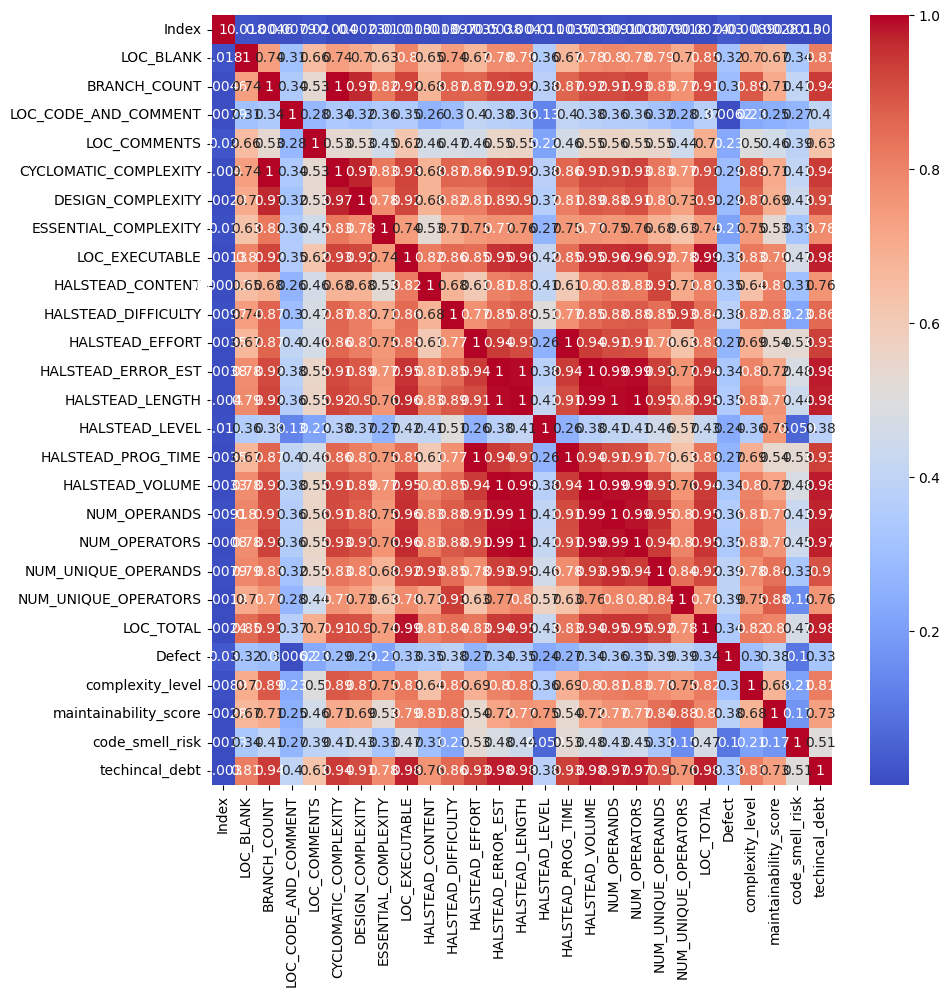

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.show()

In [24]:
# removing highly correlated features as this correlation if feature to feature
upper=corr_matrix.where(np.triu(np.ones(corr_matrix.shape),k=1).astype(bool))
protected_columns=['complexity_level','maintainability_score','techincal_debt']


to_drop=[column for column in upper.columns if any(upper[column]>0.85) and column not in protected_columns]
train=train.drop(columns=to_drop)
test=test.drop(columns=to_drop)


In [26]:
print(to_drop)

['CYCLOMATIC_COMPLEXITY', 'DESIGN_COMPLEXITY', 'LOC_EXECUTABLE', 'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_ERROR_EST', 'HALSTEAD_LENGTH', 'HALSTEAD_PROG_TIME', 'HALSTEAD_VOLUME', 'NUM_OPERANDS', 'NUM_OPERATORS', 'NUM_UNIQUE_OPERANDS', 'NUM_UNIQUE_OPERATORS', 'LOC_TOTAL']


In [25]:
print(test.columns)

Index(['Index', 'LOC_BLANK', 'BRANCH_COUNT', 'LOC_CODE_AND_COMMENT',
       'LOC_COMMENTS', 'ESSENTIAL_COMPLEXITY', 'HALSTEAD_CONTENT',
       'HALSTEAD_LEVEL', 'complexity_level', 'maintainability_score',
       'code_smell_risk', 'techincal_debt'],
      dtype='object')


In [18]:
tco=train.corr()["Defect"].sort_values(ascending=False)
print(tco)

Defect                   1.000000
HALSTEAD_CONTENT         0.349754
techincal_debt           0.327939
LOC_BLANK                0.318173
complexity_level         0.304807
BRANCH_COUNT             0.296736
LOC_COMMENTS             0.231626
ESSENTIAL_COMPLEXITY     0.213903
code_smell_risk          0.100025
Index                    0.029782
LOC_CODE_AND_COMMENT     0.006153
HALSTEAD_LEVEL          -0.236447
maintainability_score   -0.375827
Name: Defect, dtype: float64


seperating features and target


In [27]:
# data preprocesing
train['Defect']=train['Defect'].map({"Y":1 ,"N":0})
train=train.drop(columns=["Index"])


In [28]:
x_train=train.drop(columns=["Defect"],axis=1)
y_train=train["Defect"]


In [33]:
# checking for infinity and null values
print("Infinity value:" , np.isinf(x_train).sum())
print("Null value:", np.isnan(x_train).sum())

Infinity value: LOC_BLANK                  0
BRANCH_COUNT               0
LOC_CODE_AND_COMMENT       0
LOC_COMMENTS               0
ESSENTIAL_COMPLEXITY       0
HALSTEAD_CONTENT           0
HALSTEAD_LEVEL             0
complexity_level           0
maintainability_score    111
code_smell_risk            0
techincal_debt             0
dtype: int64
Null value: LOC_BLANK                0
BRANCH_COUNT             0
LOC_CODE_AND_COMMENT     0
LOC_COMMENTS             0
ESSENTIAL_COMPLEXITY     0
HALSTEAD_CONTENT         0
HALSTEAD_LEVEL           0
complexity_level         0
maintainability_score    0
code_smell_risk          0
techincal_debt           0
dtype: int64


In [34]:
x_train=x_train.replace([np.inf ,-np.inf],np.nan)
test=test.replace([np.inf ,-np.inf],np.nan)

In [21]:
# normalize data

In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
test=scaler.fit_transform(test)
